In [191]:
import pandas as pd
import numpy as np
import sqlite3

df_synop = pd.read_csv(
    "synop_2025.csv.gz",
    sep=";",
    low_memory=False
)
df_stations = pd.read_csv(
    "observations-liste-stations-synop-omm-20250710.csv",
    sep=";"
)

In [192]:
df_synop.head()

,lat,lon,geo_id_wmo,geo_id_wigos,name,reference_time,insert_time,validity_time,pmer,tend,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
0,50.136000,1.834000,7005,0-20000-0-07005,ABBEVILLE,NaN,NaN,2025-01-01T00:00:00Z,102190.0,-160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,44.571167,6.508667,7591,0-20000-0-07591,EMBRUN,NaN,NaN,2025-01-01T00:00:00Z,NaN,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,49.389500,1.178333,7037,0-20000-0-07037,ROUEN-BOOS,NaN,NaN,2025-01-01T00:00:00Z,102480.0,-140.0,...,540.0,8.0,NaN,930.0,NaN,NaN,NaN,NaN,NaN,NaN
3,43.909833,-0.500167,7607,0-20000-0-07607,MONT-DE-MARSAN,NaN,NaN,2025-01-01T00:00:00Z,103150.0,-30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-66.663167,140.001000,89642,0-20000-0-89642,DUMONT D'URVILLE,NaN,NaN,2025-01-01T00:00:00Z,97870.0,100.0,...,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [193]:
df_synop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297699 entries, 0 to 297698
Data columns (total 65 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   lat             297699 non-null  float64
 1   lon             297699 non-null  float64
 2   geo_id_wmo      297699 non-null  int64  
 3   geo_id_wigos    297699 non-null  object 
 4   name            297699 non-null  object 
 5   reference_time  178587 non-null  object 
 6   insert_time     178587 non-null  object 
 7   validity_time   297699 non-null  object 
 8   pmer            283054 non-null  float64
 9   tend            295286 non-null  float64
 10  cod_tend        295286 non-null  float64
 11  dd              295437 non-null  float64
 12  ff              295437 non-null  float64
 13  t               296339 non-null  float64
 14  td              293100 non-null  float64
 15  u               293264 non-null  float64
 16  vv              232574 non-null  float64
 17  ww        

In [194]:
df_synop.columns


Index(['lat', 'lon', 'geo_id_wmo', 'geo_id_wigos', 'name', 'reference_time',
       'insert_time', 'validity_time', 'pmer', 'tend', 'cod_tend', 'dd', 'ff',
       't', 'td', 'u', 'vv', 'ww', 'w1', 'w2', 'n', 'nbas', 'hbas', 'cl', 'cm',
       'ch', 'pres', 'niv_bar', 'geop', 'tend24', 'tn12', 'tn24', 'tx12',
       'tx24', 'tminsol', 'sw', 'tw', 'raf10', 'rafper', 'per', 'etat_sol',
       'ht_neige', 'ssfrai', 'perssfrai', 'rr1', 'rr3', 'rr6', 'rr12', 'rr24',
       'phenspe1', 'phenspe2', 'phenspe3', 'phenspe4', 'nnuage1', 'ctype1',
       'hnuage1', 'nnuage2', 'ctype2', 'hnuage2', 'nnuage3', 'ctype3',
       'hnuage3', 'nnuage4', 'ctype4', 'hnuage4'],
      dtype='object')

In [195]:
df_synop.shape

(297699, 65)

In [196]:
df_synop.describe()

,lat,lon,geo_id_wmo,pmer,tend,cod_tend,dd,ff,t,td,...,hnuage1,nnuage2,ctype2,hnuage2,nnuage3,ctype3,hnuage3,nnuage4,ctype4,hnuage4
count,297699.000000,297699.000000,297699.000000,283054.000000,295286.000000,295286.000000,295437.000000,295437.000000,296339.000000,293100.000000,...,143595.000000,75562.000000,11384.000000,75562.000000,36206.000000,6456.000000,36206.000000,245.000000,10604.000000,245.000000
mean,32.584890,1.499396,23921.726734,101565.398934,17.940641,4.311674,170.771772,3.819653,288.007883,283.660371,...,1636.436993,5.842236,4.936753,2266.288611,6.726261,6.496902,2497.143291,3.612245,8.340909,4615.061224
std,27.394634,44.761900,29955.453860,810.658219,119.803038,2.715790,101.420984,2.976488,8.884413,7.963076,...,1748.444855,1.871298,3.016958,1875.203832,1.324808,3.171961,1821.057397,2.295901,1.058178,2798.450189
min,-66.663167,-178.121000,7002.000000,94950.000000,-2840.000000,0.000000,0.000000,0.000000,243.150000,223.950000,...,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,500.000000
25%,41.921833,-0.691333,7197.000000,101160.000000,-60.000000,2.000000,90.000000,1.800000,282.050000,279.050000,...,510.000000,5.000000,3.000000,950.000000,6.000000,5.000000,1230.000000,1.000000,8.000000,1800.000000
50%,44.830667,2.397000,7524.000000,101620.000000,20.000000,3.000000,170.000000,3.000000,287.250000,283.250000,...,960.000000,6.000000,6.000000,1560.000000,7.000000,8.000000,1800.000000,3.000000,8.000000,4500.000000
75%,47.990667,5.959833,7790.000000,102080.000000,90.000000,7.000000,250.000000,5.000000,294.950000,288.450000,...,1980.000000,7.000000,8.000000,2880.000000,8.000000,9.000000,3120.000000,6.000000,9.000000,7500.000000
max,51.055833,167.241167,91958.000000,104330.000000,2990.000000,8.000000,360.000000,36.000000,314.050000,303.050000,...,9500.000000,8.000000,9.000000,9000.000000,8.000000,9.000000,9000.000000,8.000000,9.000000,9000.000000


In [197]:
df_synop.isnull().sum()

,0
lat,0
lon,0
geo_id_wmo,0
geo_id_wigos,0
name,0
...,...
ctype3,291243
hnuage3,261493
nnuage4,297454
ctype4,287095


In [198]:
df_synop.duplicated().sum()

np.int64(6712)

In [199]:
df_synop = df_synop.drop_duplicates()

print("Nombre de doublons :", df_synop.duplicated().sum())

print(df_synop.shape)

Nombre de doublons : 0
(290987, 65)


In [200]:
colonnes_vides = [
    "sw",
    "tw",
    "phenspe1",
    "phenspe2",
    "phenspe3",
    "phenspe4"
]

df_synop = df_synop.drop(columns=colonnes_vides)

In [201]:
df_synop.shape

(290987, 59)

In [202]:
df_stations.head()

,ID,Nom,Latitude,Longitude,Altitude
0,7005,ABBEVILLE,50.136000,1.834000,69
1,7015,LILLE-LESQUIN,50.570000,3.097500,47
2,7020,PTE DE LA HAGUE,49.725167,-1.939833,6
3,7027,CAEN-CARPIQUET,49.180000,-0.456167,67
4,7037,ROUEN-BOOS,49.383000,1.181667,151


In [203]:
df_stations.shape

(62, 5)

In [204]:
df_stations.columns

Index(['ID', 'Nom', 'Latitude', 'Longitude', 'Altitude'], dtype='object')

In [205]:
df_stations

,ID,Nom,Latitude,Longitude,Altitude
0,7005,ABBEVILLE,50.136000,1.834000,69
1,7015,LILLE-LESQUIN,50.570000,3.097500,47
2,7020,PTE DE LA HAGUE,49.725167,-1.939833,6
3,7027,CAEN-CARPIQUET,49.180000,-0.456167,67
4,7037,ROUEN-BOOS,49.383000,1.181667,151
...,...,...,...,...,...
57,81401,SAINT LAURENT,5.485500,-54.031667,5
58,81405,CAYENNE-MATOURY,4.822333,-52.365333,4
59,81408,SAINT GEORGES,3.890667,-51.804667,6
60,81415,MARIPASOULA,3.640167,-54.028333,106


In [206]:
stations_occitanie = [7535,7558,7621,7627,7630,7643,7747]

df_region = df_synop[
    df_synop["geo_id_wmo"].isin(stations_occitanie)
].copy()

In [207]:
df_region.shape

(19656, 59)

In [208]:
df_region[
    ["geo_id_wmo", "name"]
].drop_duplicates().sort_values("geo_id_wmo")

,geo_id_wmo,name
29,7535,GOURDON
28,7558,MILLAU
5,7621,TARBES-LOURDES-PYRENEES
6,7627,ST GIRONS
8,7630,TOULOUSE-BLAGNAC
10,7643,MONTPELLIER-AEROPORT
14,7747,PERPIGNAN


In [209]:
df_region["name"].value_counts()

,count
name,
ST GIRONS,2922
TARBES-LOURDES-PYRENEES,2921
TOULOUSE-BLAGNAC,2921
PERPIGNAN,2914
MILLAU,2848
GOURDON,2786
MONTPELLIER-AEROPORT,2344


In [210]:
df_region["validity_time"] = pd.to_datetime(
    df_region["validity_time"],
    errors="coerce",
    utc=True
)

In [211]:
print("Première date :", df_region["validity_time"].min())
print("Dernière date :", df_region["validity_time"].max())

Première date : 2025-01-01 00:00:00+00:00
Dernière date : 2025-12-31 21:00:00+00:00


In [212]:
df_region = df_region.dropna(
    subset=["validity_time"]
).copy()

In [213]:
df_region = df_region.sort_values(
    ["geo_id_wmo", "validity_time"]
).reset_index(drop=True)

In [214]:
colonnes_utiles = [
    "validity_time",
    "geo_id_wmo",
    "name",
    "lat",
    "lon",
    "pmer",
    "tend",
    "dd",
    "ff",
    "t",
    "td",
    "u",
    "vv",
    "n",
    "rr1"
]

In [215]:
df_prepare = df_region[colonnes_utiles].copy()

In [216]:
df_prepare["validity_time"] = pd.to_datetime(
    df_prepare["validity_time"],
    errors="coerce",
    utc=True)

df_prepare = df_prepare.dropna(
    subset=["validity_time"]).copy()

df_prepare = df_prepare.sort_values(
    ["geo_id_wmo", "validity_time"]).reset_index(drop=True)

print(df_prepare["validity_time"].dtype)
print(df_prepare.shape)

datetime64[ns, UTC]
(19656, 15)


In [217]:
df_prepare["date_suivante"] = (
    df_prepare
    .groupby("geo_id_wmo")["validity_time"]
    .shift(-1))

df_prepare["rr1_suivant"] = (
    df_prepare
    .groupby("geo_id_wmo")["rr1"]
    .shift(-1))


df_prepare["delai_heures"] = (df_prepare["date_suivante"] - df_prepare["validity_time"]).dt.total_seconds() / 3600

In [218]:
df_prepare["delai_heures"].value_counts().sort_index()

,count
delai_heures,
0.0,48
3.0,19108
6.0,335
9.0,96
12.0,38
15.0,7
18.0,7
21.0,2
27.0,1


In [219]:
df_prepare = df_prepare[
    (df_prepare["delai_heures"] == 3)
    & (df_prepare["rr1_suivant"].notna())].copy()

In [220]:
df_prepare["pluie_prochaine_3h"] = (
    df_prepare["rr1_suivant"] > 0).astype(int)

In [221]:
df_prepare = df_prepare.drop(
    columns=[
        "date_suivante",
        "rr1_suivant",
        "delai_heures"
    ])

print(df_prepare.shape)

(18982, 16)


In [222]:
df_prepare["temperature_c"] = (df_prepare["t"] - 273.15)

df_prepare["point_rosee_c"] = (df_prepare["td"] - 273.15)

df_prepare["pression_hpa"] = (df_prepare["pmer"] / 100)

df_prepare["tendance_pression_hpa"] = (df_prepare["tend"] / 100)

In [223]:
df_prepare = df_prepare.drop(
    columns=[
        "t",
        "td",
        "pmer",
        "tend"
    ])


In [224]:
df_prepare["mois"] = (
    df_prepare["validity_time"].dt.month
)

df_prepare["jour"] = (
    df_prepare["validity_time"].dt.day
)

df_prepare["heure"] = (
    df_prepare["validity_time"].dt.hour
)

df_prepare["jour_semaine"] = (
    df_prepare["validity_time"].dt.dayofweek
)

In [225]:
def determiner_saison(mois):
    if mois in [12, 1, 2]:
        return 0
    elif mois in [3, 4, 5]:
        return 1
    elif mois in [6, 7, 8]:
        return 2
    else:
        return 3

In [226]:
df_prepare["saison"] = (
    df_prepare["mois"]
    .apply(determiner_saison))

In [227]:
print("Effectifs :")
print(df_prepare["pluie_prochaine_3h"].value_counts())

print("\nPourcentages :")
print(df_prepare["pluie_prochaine_3h"].value_counts(normalize=True) * 100)

Effectifs :
pluie_prochaine_3h
0    17542
1     1440
Name: count, dtype: int64

Pourcentages :
pluie_prochaine_3h
0    92.413866
1     7.586134
Name: proportion, dtype: float64


In [228]:
class_weight="balanced"

In [229]:
valeurs_manquantes = (
    df_prepare
    .isna()
    .sum()
    .sort_values(ascending=False))

valeurs_manquantes

,0
n,10891
point_rosee_c,94
pression_hpa,94
temperature_c,94
vv,86
rr1,86
tendance_pression_hpa,6
ff,4
dd,4
u,3


In [230]:
pourcentage_manquant = (
    df_prepare
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False))

pourcentage_manquant

,0
n,57.375408
point_rosee_c,0.495206
pression_hpa,0.495206
temperature_c,0.495206
vv,0.453061
rr1,0.453061
tendance_pression_hpa,0.031609
ff,0.021073
dd,0.021073
u,0.015804


In [231]:
df_prepare = df_prepare.drop(
    columns=["n"])

In [232]:
print("Dimensions finales :", df_prepare.shape)

print("\nColonnes :")
print(df_prepare.columns.tolist())

print("\nValeurs manquantes restantes :")
print(
    df_prepare
    .isna()
    .sum()
    .sort_values(ascending=False))

print( "\nDoublons :",df_prepare.duplicated().sum())

Dimensions finales : (18982, 20)

Colonnes :
['validity_time', 'geo_id_wmo', 'name', 'lat', 'lon', 'dd', 'ff', 'u', 'vv', 'rr1', 'pluie_prochaine_3h', 'temperature_c', 'point_rosee_c', 'pression_hpa', 'tendance_pression_hpa', 'mois', 'jour', 'heure', 'jour_semaine', 'saison']

Valeurs manquantes restantes :
point_rosee_c            94
pression_hpa             94
temperature_c            94
vv                       86
rr1                      86
tendance_pression_hpa     6
ff                        4
dd                        4
u                         3
name                      0
geo_id_wmo                0
validity_time             0
lat                       0
lon                       0
pluie_prochaine_3h        0
mois                      0
jour                      0
heure                     0
jour_semaine              0
saison                    0
dtype: int64

Doublons : 0


In [233]:
df_prepare = (
    df_prepare
    .drop_duplicates()
    .reset_index(drop=True))

In [234]:
connexion = sqlite3.connect(
    "goutte_eau.db")

df_stations.to_sql(
    name="stations",
    con=connexion,
    if_exists="replace",
    index=False)

df_prepare.to_sql(
    name="observations_meteo",
    con=connexion,
    if_exists="replace",
    index=False)

18982

In [235]:
requete_tables = """
SELECT name
FROM sqlite_master
WHERE type = 'table';
"""

pd.read_sql_query(requete_tables,connexion)

,name
0,stations
1,observations_meteo


In [236]:
requete_nombre = """
SELECT COUNT(*) AS nombre_observations
FROM observations_meteo;
"""

pd.read_sql_query(
    requete_nombre,
    connexion)

,nombre_observations
0,18982


In [237]:
requete_stations = """
SELECT DISTINCT
    geo_id_wmo,
    name
FROM observations_meteo
ORDER BY geo_id_wmo;
"""

pd.read_sql_query(
    requete_stations,
    connexion
)

,geo_id_wmo,name
0,7535,GOURDON
1,7558,MILLAU
2,7621,TARBES-LOURDES-PYRENEES
3,7627,ST GIRONS
4,7630,TOULOUSE-BLAGNAC
5,7643,MONTPELLIER-AEROPORT
6,7747,PERPIGNAN


In [238]:
connexion.close()

In [239]:
connexion = sqlite3.connect("goutte_eau.db")

df_model = pd.read_sql_query(
    """
    SELECT *
    FROM observations_meteo
    ORDER BY geo_id_wmo, validity_time;
    """, connexion)

connexion.close()

In [240]:
df_model["validity_time"] = pd.to_datetime(
    df_model["validity_time"],
    errors="coerce",
    utc=True)

df_model = df_model.dropna(
    subset=["validity_time"]).copy()

df_model = df_model.sort_values(
    ["geo_id_wmo", "validity_time"]).reset_index(drop=True)

In [241]:
features = [
    "lat",
    "lon",
    "dd",
    "ff",
    "u",
    "vv",
    "rr1",
    "temperature_c",
    "point_rosee_c",
    "pression_hpa",
    "tendance_pression_hpa",
    "mois",
    "jour",
    "heure",
    "jour_semaine",
    "saison"
]

target = "pluie_prochaine_3h"

In [242]:
train_parts = []
test_parts = []

for station_id, groupe in df_model.groupby(
    "geo_id_wmo"
):
    groupe = groupe.sort_values(
        "validity_time"
    ).copy()

    indice_station = int(
        len(groupe) * 0.80
    )

    train_parts.append(
        groupe.iloc[:indice_station]
    )

    test_parts.append(
        groupe.iloc[indice_station:]
    )

In [243]:
train_parts = []
test_parts = []

for station_id, groupe in df_model.groupby(
    "geo_id_wmo"):

    groupe = groupe.sort_values(
        "validity_time").copy()

    indice_station = int(len(groupe) * 0.80)

    train_parts.append(groupe.iloc[:indice_station])

    test_parts.append(groupe.iloc[indice_station:])

In [244]:
df_train = (
    pd.concat(train_parts)
    .sort_values(
        ["validity_time", "geo_id_wmo"])
    .reset_index(drop=True))

df_test = (
    pd.concat(test_parts)
    .sort_values(
        ["validity_time", "geo_id_wmo"])
    .reset_index(drop=True))

In [245]:
X_train = df_train[features].copy()
y_train = df_train[target].copy()

X_test = df_test[features].copy()
y_test = df_test[target].copy()

In [246]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

print("\nRépartition entraînement :")
print(y_train.value_counts(normalize=True) * 100)

print("\nRépartition test :")
print(y_test.value_counts(normalize=True) * 100)

X_train : (15182, 16)
X_test : (3800, 16)
y_train : (15182,)
y_test : (3800,)

Répartition entraînement :
pluie_prochaine_3h
0    93.202477
1     6.797523
Name: proportion, dtype: float64

Répartition test :
pluie_prochaine_3h
0    89.263158
1    10.736842
Name: proportion, dtype: float64


In [247]:
for station_id in sorted(
    df_model["geo_id_wmo"].unique()
):
    train_station = df_train[
        df_train["geo_id_wmo"]
        == station_id
    ]

    test_station = df_test[
        df_test["geo_id_wmo"]
        == station_id
    ]

    print(
        station_id,
        "| fin train :",
        train_station[
            "validity_time"
        ].max(),
        "| début test :",
        test_station[
            "validity_time"
        ].min()
    )

7535 | fin train : 2025-10-24 15:00:00+00:00 | début test : 2025-10-24 18:00:00+00:00
7558 | fin train : 2025-10-18 03:00:00+00:00 | début test : 2025-10-18 06:00:00+00:00
7621 | fin train : 2025-10-19 21:00:00+00:00 | début test : 2025-10-20 00:00:00+00:00
7627 | fin train : 2025-10-21 21:00:00+00:00 | début test : 2025-10-22 00:00:00+00:00
7630 | fin train : 2025-10-19 21:00:00+00:00 | début test : 2025-10-20 00:00:00+00:00
7643 | fin train : 2025-11-14 00:00:00+00:00 | début test : 2025-11-14 03:00:00+00:00
7747 | fin train : 2025-10-20 03:00:00+00:00 | début test : 2025-10-20 06:00:00+00:00


In [248]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)

In [249]:
modele_reference = DummyClassifier(
    strategy="most_frequent"
)

modele_reference.fit(
    X_train,
    y_train
)

prediction_reference = modele_reference.predict(
    X_test
)

accuracy_reference = accuracy_score(
    y_test,
    prediction_reference
)

precision_reference = precision_score(
    y_test,
    prediction_reference,
    zero_division=0
)

recall_reference = recall_score(
    y_test,
    prediction_reference,
    zero_division=0
)

f1_reference = f1_score(
    y_test,
    prediction_reference,
    zero_division=0
)

print("Accuracy :", accuracy_reference)
print("Precision :", precision_reference)
print("Recall :", recall_reference)
print("F1-score :", f1_reference)

print(
    classification_report(
        y_test,
        prediction_reference,
        zero_division=0
    )
)

matrice_reference = confusion_matrix(
    y_test,
    prediction_reference
)

print(matrice_reference)

Accuracy : 0.8926315789473684
Precision : 0.0
Recall : 0.0
F1-score : 0.0
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3392
           1       0.00      0.00      0.00       408

    accuracy                           0.89      3800
   macro avg       0.45      0.50      0.47      3800
weighted avg       0.80      0.89      0.84      3800

[[3392    0]
 [ 408    0]]


In [250]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [251]:
modele_lr = Pipeline([
    (
        "imputation",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "standardisation",
        StandardScaler()
    ),
    (
        "classification",
        LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        )
    )
])

In [252]:
modele_lr.fit(
    X_train,
    y_train)

Pipeline(steps=[('imputation', SimpleImputer(strategy='median')),
                ('standardisation', StandardScaler()),
                ('classification',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [253]:
prediction_lr = modele_lr.predict(X_test)

In [254]:
probabilite_lr = (modele_lr.predict_proba(X_test)[:, 1])

In [255]:
accuracy_lr = accuracy_score(
    y_test,
    prediction_lr)

precision_lr = precision_score(
    y_test,
    prediction_lr,
    zero_division=0)

recall_lr = recall_score(
    y_test,
    prediction_lr,
    zero_division=0)

f1_lr = f1_score(
    y_test,
    prediction_lr,
    zero_division=0)

print("Accuracy :", accuracy_lr)
print("Precision :", precision_lr)
print("Recall :", recall_lr)
print("F1-score :", f1_lr)

print(classification_report(
        y_test,
        prediction_lr,
        zero_division=0))

matrice_lr = confusion_matrix(
    y_test,
    prediction_lr)

print(matrice_lr)

Accuracy : 0.7218421052631578
Precision : 0.24509033778476041
Recall : 0.7647058823529411
F1-score : 0.37120761451516954
              precision    recall  f1-score   support

           0       0.96      0.72      0.82      3392
           1       0.25      0.76      0.37       408

    accuracy                           0.72      3800
   macro avg       0.60      0.74      0.60      3800
weighted avg       0.89      0.72      0.77      3800

[[2431  961]
 [  96  312]]


In [256]:
from sklearn.ensemble import RandomForestClassifier

modele_rf = Pipeline([
    (
        "imputation",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "classification",
        RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42
        )
    )
])

modele_rf.fit(
    X_train,
    y_train
)

prediction_rf = modele_rf.predict(
    X_test
)

probabilite_rf = modele_rf.predict_proba(
    X_test
)[:, 1]

accuracy_rf = accuracy_score(
    y_test,
    prediction_rf
)

precision_rf = precision_score(
    y_test,
    prediction_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    prediction_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    prediction_rf,
    zero_division=0
)

print("Accuracy :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall :", recall_rf)
print("F1-score :", f1_rf)

print(
    classification_report(
        y_test,
        prediction_rf,
        zero_division=0
    )
)

matrice_rf = confusion_matrix(
    y_test,
    prediction_rf
)

print(matrice_rf)

Accuracy : 0.8926315789473684
Precision : 0.0
Recall : 0.0
F1-score : 0.0
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      3392
           1       0.00      0.00      0.00       408

    accuracy                           0.89      3800
   macro avg       0.45      0.50      0.47      3800
weighted avg       0.80      0.89      0.84      3800

[[3392    0]
 [ 408    0]]


In [257]:
resultats_modeles = pd.DataFrame({
    "Modèle": [
        "DummyClassifier",
        "Régression Logistique",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_reference,
        accuracy_lr,
        accuracy_rf
    ],
    "Precision_pluie": [
        precision_reference,
        precision_lr,
        precision_rf
    ],
    "Recall_pluie": [
        recall_reference,
        recall_lr,
        recall_rf
    ],
    "F1_pluie": [
        f1_reference,
        f1_lr,
        f1_rf
    ]
})

resultats_modeles.round(3)


,Modèle,Accuracy,Precision_pluie,Recall_pluie,F1_pluie
0,DummyClassifier,0.893,0.000,0.000,0.000
1,Régression Logistique,0.722,0.245,0.765,0.371
2,Random Forest,0.893,0.000,0.000,0.000


In [258]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    probabilite_lr
)

print("ROC AUC :", auc)

ROC AUC : 0.8223812372826489


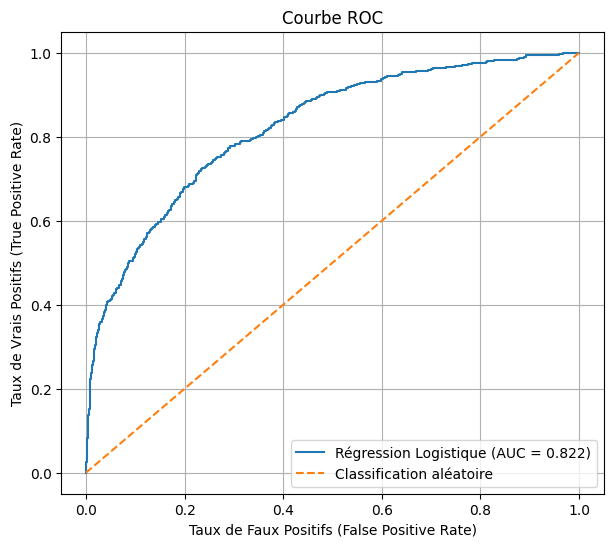

In [259]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, seuils = roc_curve(
    y_test,
    probabilite_lr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"Régression Logistique (AUC = {auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Classification aléatoire")

plt.xlabel("Taux de Faux Positifs (False Positive Rate)")
plt.ylabel("Taux de Vrais Positifs (True Positive Rate)")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)

plt.show()

In [260]:
import joblib

joblib.dump(
    modele_lr,
    "modele_pluie.joblib"
)

joblib.dump(
    features,
    "features_modele.joblib")

print("Modèle et liste des variables sauvegardés.")

Modèle et liste des variables sauvegardés.


In [261]:
import os

print(os.path.exists("modele_pluie.joblib"))
print(os.path.exists("features_modele.joblib"))

True
True


In [262]:
modele_charge = joblib.load("modele_pluie.joblib")

features_chargees = joblib.load(
    "features_modele.joblib"
)

print(features_chargees)

['lat', 'lon', 'dd', 'ff', 'u', 'vv', 'rr1', 'temperature_c', 'point_rosee_c', 'pression_hpa', 'tendance_pression_hpa', 'mois', 'jour', 'heure', 'jour_semaine', 'saison']


In [263]:
exemple_test = X_test.head(5)

predictions_test = modele_charge.predict(
    exemple_test
)

probabilites_test = modele_charge.predict_proba(
    exemple_test
)[:, 1]

print("Prédictions :", predictions_test)
print("Probabilités :", probabilites_test)

Prédictions : [0 0 0 0 0]
Probabilités : [0.20932154 0.1842922  0.06956489 0.07525426 0.1487668 ]


In [264]:
fichiers = [
    "modele_pluie.joblib",
    "features_modele.joblib",
    "goutte_eau.db"
]

for fichier in fichiers:
    print(fichier, os.path.exists(fichier))

modele_pluie.joblib True
features_modele.joblib True
goutte_eau.db True


In [265]:
%%writefile app.py

from flask import Flask, jsonify, request
import joblib
import pandas as pd
import sqlite3

app = Flask(__name__)

MODELE_PATH = "modele_pluie.joblib"
FEATURES_PATH = "features_modele.joblib"
DATABASE_PATH = "goutte_eau.db"

modele = joblib.load(MODELE_PATH)
features = joblib.load(FEATURES_PATH)


def determiner_saison(mois):
    if mois in [12, 1, 2]:
        return 0
    elif mois in [3, 4, 5]:
        return 1
    elif mois in [6, 7, 8]:
        return 2
    return 3


def recuperer_observation(date_sql, station_id):
    connexion = sqlite3.connect(DATABASE_PATH)

    requete = """
    SELECT
        validity_time,
        geo_id_wmo,
        name,
        lat,
        lon,
        dd,
        ff,
        u,
        vv,
        rr1,
        temperature_c,
        point_rosee_c,
        pression_hpa,
        tendance_pression_hpa
    FROM observations_meteo
    WHERE validity_time = ?
      AND geo_id_wmo = ?
    LIMIT 1
    """

    observation = pd.read_sql_query(
        requete,
        connexion,
        params=(date_sql, station_id)
    )

    connexion.close()
    return observation


@app.route("/", methods=["GET"])
def accueil():
    return jsonify({
        "nom": "API Goutte d'Eau",
        "description": "Estimation du risque de pluie à trois heures",
        "routes": {
            "sante": "GET /health",
            "stations": "GET /stations",
            "prediction": "POST /predict"
        }
    })


@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "ok",
        "modele": "Régression Logistique"
    })


@app.route("/stations", methods=["GET"])
def stations():
    connexion = sqlite3.connect(DATABASE_PATH)

    resultat = pd.read_sql_query(
        """
        SELECT DISTINCT
            geo_id_wmo AS station_id,
            name AS station
        FROM observations_meteo
        ORDER BY geo_id_wmo
        """,
        connexion
    )

    connexion.close()

    return jsonify(
        resultat.to_dict(orient="records")
    )


@app.route("/predict", methods=["POST"])
def predict():
    contenu = request.get_json(silent=True)

    if contenu is None:
        return jsonify({
            "erreur": "Le corps doit être au format JSON."
        }), 400

    date_demandee = contenu.get("date")
    station_id = contenu.get("station_id")

    if not date_demandee or station_id is None:
        return jsonify({
            "erreur": "Les champs date et station_id sont obligatoires."
        }), 400

    try:
        station_id = int(station_id)
        date_convertie = pd.to_datetime(
            date_demandee,
            utc=True
        )
    except (TypeError, ValueError):
        return jsonify({
            "erreur": "Date ou identifiant de station invalide."
        }), 400

    date_sql = date_convertie.isoformat(sep=" ")

    observation = recuperer_observation(
        date_sql,
        station_id
    )

    if observation.empty:
        return jsonify({
            "erreur": "Aucune observation trouvée pour cette date et cette station."
        }), 404

    observation["validity_time"] = pd.to_datetime(
        observation["validity_time"],
        utc=True
    )

    observation["mois"] = observation["validity_time"].dt.month
    observation["jour"] = observation["validity_time"].dt.day
    observation["heure"] = observation["validity_time"].dt.hour
    observation["jour_semaine"] = observation["validity_time"].dt.dayofweek
    observation["saison"] = observation["mois"].apply(
        determiner_saison
    )

    X_prediction = observation[features].copy()

    classe = int(
        modele.predict(X_prediction)[0]
    )

    probabilite = float(
        modele.predict_proba(X_prediction)[0, 1]
    )

    if probabilite < 0.30:
        niveau = "faible"
    elif probabilite < 0.60:
        niveau = "modéré"
    else:
        niveau = "élevé"

    return jsonify({
        "date_observation": str(date_demandee),
        "station_id": station_id,
        "station": observation["name"].iloc[0],
        "horizon_prediction": "3 heures",
        "classe_predite": classe,
        "pluie_predite": bool(classe),
        "probabilite_pluie": round(probabilite, 4),
        "probabilite_pluie_pourcentage": round(
            probabilite * 100,
            2
        ),
        "niveau_risque": niveau
    })


if __name__ == "__main__":
    app.run(
        host="0.0.0.0",
        port=5000,
        debug=False
    )

Overwriting app.py


In [266]:
from app import app

client = app.test_client()

In [267]:
reponse = client.get("/health")

print("Code HTTP :", reponse.status_code)
print(reponse.get_json())

Code HTTP : 200
{'modele': 'Régression Logistique', 'status': 'ok'}


In [268]:
reponse = client.get("/stations")

print("Code HTTP :", reponse.status_code)
print(reponse.get_json())

Code HTTP : 200
[{'station': 'GOURDON', 'station_id': 7535}, {'station': 'MILLAU', 'station_id': 7558}, {'station': 'TARBES-LOURDES-PYRENEES', 'station_id': 7621}, {'station': 'ST GIRONS', 'station_id': 7627}, {'station': 'TOULOUSE-BLAGNAC', 'station_id': 7630}, {'station': 'MONTPELLIER-AEROPORT', 'station_id': 7643}, {'station': 'PERPIGNAN', 'station_id': 7747}]


In [269]:
connexion = sqlite3.connect("goutte_eau.db")

exemple_base = pd.read_sql_query(
    """
    SELECT
        validity_time,
        geo_id_wmo,
        name
    FROM observations_meteo
    LIMIT 1
    """,
    connexion
)

connexion.close()

exemple_base

,validity_time,geo_id_wmo,name
0,2025-01-01 00:00:00+00:00,7535,GOURDON


In [270]:
date_test = exemple_base.iloc[0]["validity_time"]
station_test = int(
    exemple_base.iloc[0]["geo_id_wmo"]
)

print(date_test)
print(station_test)

2025-01-01 00:00:00+00:00
7535


In [271]:
reponse = client.post(
    "/predict",
    json={
        "date": str(date_test),
        "station_id": station_test
    }
)

print("Code HTTP :", reponse.status_code)
print(reponse.get_json())

Code HTTP : 200
{'classe_predite': 0, 'date_observation': '2025-01-01 00:00:00+00:00', 'horizon_prediction': '3 heures', 'niveau_risque': 'faible', 'pluie_predite': False, 'probabilite_pluie': 0.1475, 'probabilite_pluie_pourcentage': 14.75, 'station': 'GOURDON', 'station_id': 7535}


In [272]:
reponse = client.post(
    "/predict",
    json={
        "date": "2030-01-01T00:00:00Z",
        "station_id": 7535
    }
)

print(reponse.status_code)
print(reponse.get_json())

404
{'erreur': 'Aucune observation trouvée pour cette date et cette station.'}


In [273]:
reponse = client.post(
    "/predict",
    json={
        "station_id": 7535
    }
)

print(reponse.status_code)
print(reponse.get_json())

400
{'erreur': 'Les champs date et station_id sont obligatoires.'}


In [181]:
!pip install gradio -q

In [182]:
import gradio as gr
import pandas as pd
import sqlite3
import joblib

In [183]:
modele = joblib.load("modele_pluie.joblib")
features = joblib.load("features_modele.joblib")

In [184]:
connexion = sqlite3.connect("goutte_eau.db")

stations_df = pd.read_sql_query(
    """
    SELECT DISTINCT
        geo_id_wmo,
        name
    FROM observations_meteo
    ORDER BY geo_id_wmo
    """,
    connexion
)

connexion.close()

stations_df

,geo_id_wmo,name
0,7535,GOURDON
1,7558,MILLAU
2,7621,TARBES-LOURDES-PYRENEES
3,7627,ST GIRONS
4,7630,TOULOUSE-BLAGNAC
5,7643,MONTPELLIER-AEROPORT
6,7747,PERPIGNAN


In [185]:
stations_choix = {
    f"{ligne['name']} ({ligne['geo_id_wmo']})": int(ligne["geo_id_wmo"])
    for _, ligne in stations_df.iterrows()
}